In [29]:
import pandas as pd

In [30]:
dataIn = "../dataIn/"

In [31]:
# 1분기 판매량
filename = dataIn + "가전제품판매량01.csv"
# 선생님께서 엑셀에서 보시려고 해당 파일의 인코딩을 CP949로 만들어 놓으심
homeware01 = pd.read_csv(filename, encoding="CP949", index_col="지역")
homeware01

,미니오븐,전기밥솥,후라이팬,분기
지역,,,,
서울,65,85,70,1
대전,90,85,65,1
대구,60,90,50,1


In [32]:
# 2분기 판매량
filename = dataIn + "가전제품판매량02.csv"
homeware02 = pd.read_csv(filename, encoding="CP949", index_col="지역")
homeware02

,미니오븐,전기밥솥,세탁기,분기
지역,,,,
서울,55,35,100,2
대전,90,85,70,2
부산,60,90,40,2


In [33]:
# 각 분기 판매량의 행 색인들 변수로 지정
columnInfo01 = homeware01.columns
columnInfo02 = homeware02.columns

# 2개의 Index 객체 (겉으로는 리스트 타입처럼 보임) 비교
# intersection() : 교집합 표현하는 함수
columnInfo01.intersection(columnInfo02)

Index(['미니오븐', '전기밥솥', '분기'], dtype='object')

In [34]:
# difference() : 차집합 표현하는 함수
# A - B를 표현 (A에만 존재하는 것 표현)
columnInfo01.difference(columnInfo02)

Index(['후라이팬'], dtype='object')

In [35]:
columnInfo02.difference(columnInfo01)

Index(['세탁기'], dtype='object')

In [36]:
# concat() : 문자열을 합치는 함수
# join="기본값은 outer"
# join="inner" : 교집합 가져오기 / 데이터베이스에서 inner join 같은 것
# 서로 짝이 맞는(공통으로 존재하는) 행이나 열만 남기고 나머지는 다 버리겠다는 뜻
# join="outer" : 합집합 가져오기
# result = pd.concat([homeware01, homeware02], join="inner")
# result

# axis=0 : 행을 기준으로 (행이 늘어난다는 뜻)
# 이때 열에 대한 내용이 기본적으로 합집합으로 나타냄
result = pd.concat([homeware01, homeware02], axis=0)
result

,미니오븐,전기밥솥,후라이팬,분기,세탁기
지역,,,,,
서울,65,85,70.0,1,NaN
대전,90,85,65.0,1,NaN
대구,60,90,50.0,1,NaN
서울,55,35,NaN,2,100.0
대전,90,85,NaN,2,70.0
부산,60,90,NaN,2,40.0


In [37]:
# axis=1 : 열을 기준으로 (행이 늘어난다는 뜻)
result = pd.concat([homeware01, homeware02], axis=1)
result

,미니오븐,전기밥솥,후라이팬,분기,미니오븐,전기밥솥,세탁기,분기
지역,,,,,,,,
서울,65.0,85.0,70.0,1.0,55.0,35.0,100.0,2.0
대전,90.0,85.0,65.0,1.0,90.0,85.0,70.0,2.0
대구,60.0,90.0,50.0,1.0,NaN,NaN,NaN,NaN
부산,NaN,NaN,NaN,NaN,60.0,90.0,40.0,2.0


In [38]:
result.columns

Index(['미니오븐', '전기밥솥', '후라이팬', '분기', '미니오븐', '전기밥솥', '세탁기', '분기'], dtype='object')

In [39]:
# 서로 원래 공통된 열이 있어서 2개의 데이터 프레임을 그냥 합치면 하나로 합쳐지는데
# 서로의 열을 따로 표시하면서 하나의 데이터 프레임을 만들기 위해서 열의 이름을 서로 다르게 만들어서 합침
homeware01.columns = ["미니오븐01", "전기밥솥01", "후라이팬01", "분기01"]
# 이런식으로 바꿔도 됨
homeware02.columns = [item + "02" for item in homeware02.columns]

In [40]:
result = pd.concat([homeware01, homeware02], axis=1)
result

,미니오븐01,전기밥솥01,후라이팬01,분기01,미니오븐02,전기밥솥02,세탁기02,분기02
지역,,,,,,,,
서울,65.0,85.0,70.0,1.0,55.0,35.0,100.0,2.0
대전,90.0,85.0,65.0,1.0,90.0,85.0,70.0,2.0
대구,60.0,90.0,50.0,1.0,NaN,NaN,NaN,NaN
부산,NaN,NaN,NaN,NaN,60.0,90.0,40.0,2.0


In [42]:
file01 = dataIn + "학생정보01.csv"
student = pd.read_csv(file01, encoding="CP949")
student

,id,이름,주소
0,kang,강유심,마포
1,shin,신서윤,용산
2,choi,최윤라,강남


In [43]:
file02 = dataIn + "시험점수01.csv"
jumsu = pd.read_csv(file02, encoding="CP949")
jumsu

,id,과목,점수
0,kang,국어,10
1,kang,영어,15
2,kang,수학,20
3,shin,국어,25
4,shin,영어,30
5,shin,수학,30


In [44]:
# 교집합으로 공통된 컬럼 정보 확인하기
# 양쪽에 동일한 이름의 컬럼이 존재하는 지 확인합니다.
col_student=student.columns
col_jumsu=jumsu.columns
col_student.intersection(col_jumsu)

Index(['id'], dtype='object')

In [45]:
# 2개의 데이터 프레임의 열 중에서 교집합인 "id" 열에 대하여 merge하기
# pd.merge() : 특정 기준 열의 값이 같은 것끼리 찾아서 가로로 '조립(병합)'하는 함수
# SQL에서 JOIN 연산과 같은 개념
# on="공통된열, 행"
result = pd.merge(student, jumsu, on='id')
result

,id,이름,주소,과목,점수
0,kang,강유심,마포,국어,10
1,kang,강유심,마포,영어,15
2,kang,강유심,마포,수학,20
3,shin,신서윤,용산,국어,25
4,shin,신서윤,용산,영어,30
5,shin,신서윤,용산,수학,30


In [60]:
# copy() : 원본 데이터는 놔두고 복사 데이터를 만들기
# chartdata03 = result 이렇게 하면 result가 변하면 chartdata03도 같이 변하는건 당연하고
# chartdata03를 바꾸면 result도 같이 변해버림 -> 데이터의 '메모리 주소'를 공유하고 있어서
chartdata03 = result.copy()
# chartdata03["id"]=="kang" : 열 색인 기준으로 값이 "kang"인 데이터를 가져오기
# -> "id"라는 이름의 열 색인에 "kang"이라는 데이터가 있는 걸 찾고 그 데이터가 있는 행들을 가져옴
# chartdata03.index == "행 색인 이름" : 행 색인 기준으로 데이터 가져올때
# -> 열 색인 기준으로 가져올때는 열 색인 이름과 그 값에 대해서 찾고 그에 해당하는 행들을 가져오지만
# -> 행 색인 기준으로 가져올때는 행 색인의 이름(레이블) 자체를 찾고 그에 해당하는 행들을 가져옴
chartdata03 = chartdata03.loc[chartdata03["id"]=="kang", ["과목", "점수"]]
# set_index("기존에 있던 열 색인") : 열 색인을 행 색인으로 바꾸는 함수
chartdata03 = chartdata03.set_index("과목")
chartdata03

,점수
과목,
국어,10
영어,15
수학,20


In [61]:
# 데이터 프레임을 기반으로 그래프 그리기
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

Text(0.5, 1.0, '과목별 점수 비율')

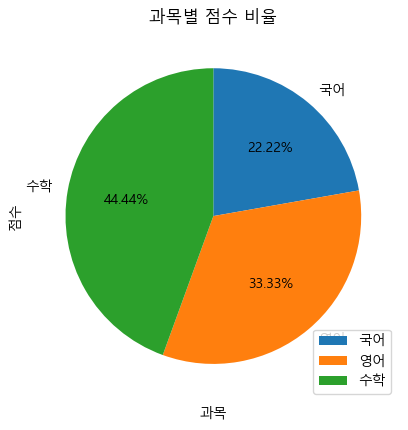

In [62]:
mylabel = chartdata03.index
chartdata03.plot(y='점수', kind='pie', labels=mylabel, shadow=False, \
         autopct='%1.2f%%', startangle=90, counterclock=False)
plt.grid(True)
plt.legend(loc=4)
plt.xlabel(chartdata03.index.name)
plt.title('과목별 점수 비율')

In [63]:
# merge() 메소드의 다양한 옵션
# how 옵션 사용해보기
result = pd.merge(student, jumsu, on='id', how="outer")
result

,id,이름,주소,과목,점수
0,choi,최윤라,강남,NaN,NaN
1,kang,강유심,마포,국어,10.0
2,kang,강유심,마포,영어,15.0
3,kang,강유심,마포,수학,20.0
4,shin,신서윤,용산,국어,25.0
5,shin,신서윤,용산,영어,30.0
6,shin,신서윤,용산,수학,30.0


In [64]:
result = pd.merge(student, jumsu, on='id', how="left")
result

,id,이름,주소,과목,점수
0,kang,강유심,마포,국어,10.0
1,kang,강유심,마포,영어,15.0
2,kang,강유심,마포,수학,20.0
3,shin,신서윤,용산,국어,25.0
4,shin,신서윤,용산,영어,30.0
5,shin,신서윤,용산,수학,30.0
6,choi,최윤라,강남,NaN,NaN


In [65]:
result = pd.merge(student, jumsu, on='id', how="right")
result

,id,이름,주소,과목,점수
0,kang,강유심,마포,국어,10
1,kang,강유심,마포,영어,15
2,kang,강유심,마포,수학,20
3,shin,신서윤,용산,국어,25
4,shin,신서윤,용산,영어,30
5,shin,신서윤,용산,수학,30


In [66]:
# 데이터 프레임의 컬럼 이름이 다른 경우
file01 = dataIn + "학생정보02.csv"
student = pd.read_csv(file01, encoding="CP949")
student

,leftid,이름,주소
0,kang,강유심,마포
1,shin,신서윤,용산
2,choi,최윤라,강남


In [67]:
file02 = dataIn + "시험점수02.csv"
jumsu = pd.read_csv(file02, encoding="CP949")
jumsu

,rightid,과목,점수
0,kang,국어,10
1,kang,영어,15
2,kang,수학,20
3,shin,국어,25
4,shin,영어,30
5,shin,수학,30


In [69]:
# left_on, right_on 옵션 사용 (Python(이론).pdf (P.285))
result = pd.merge(student, jumsu, left_on='leftid', right_on='rightid')
result

,leftid,이름,주소,rightid,과목,점수
0,kang,강유심,마포,kang,국어,10
1,kang,강유심,마포,kang,영어,15
2,kang,강유심,마포,kang,수학,20
3,shin,신서윤,용산,shin,국어,25
4,shin,신서윤,용산,shin,영어,30
5,shin,신서윤,용산,shin,수학,30


In [70]:
# 여러 개의 컬럼 병합하기
file01 = dataIn + "시험점수03.csv"
data01 = pd.read_csv(file01, encoding='CP949')
data01

,이름,과목,중간고사
0,강호섭,국어,10
1,강호섭,영어,15
2,강호섭,수학,20
3,윤진혁,국어,25
4,윤진혁,영어,30
5,윤진혁,수학,30


In [71]:
file02 = dataIn + "시험점수04.csv"
data02 = pd.read_csv(file02, encoding='CP949')
data02

,이름,과목,기말고사
0,강호섭,국어,15
1,강호섭,영어,25
2,강호섭,수학,35
3,윤진혁,국어,45
4,윤진혁,영어,55


In [73]:
# on 옵션 사용해보기
# 양쪽 프레임에 동일 개념의 컬럼이 2개 이상인 경우
on_condition = ["이름", "과목"]
result = pd.merge(data01, data02, on=on_condition, how="outer")
result

,이름,과목,중간고사,기말고사
0,강호섭,국어,10,15.0
1,강호섭,수학,20,35.0
2,강호섭,영어,15,25.0
3,윤진혁,국어,25,45.0
4,윤진혁,수학,30,NaN
5,윤진혁,영어,30,55.0


In [74]:
# on, how 옵션 사용해보기
file01 = dataIn + "시험점수05.csv"
data01 = pd.read_csv(file01, encoding='CP949')
data01

,이름,과목,시험
0,강호섭,국어,10
1,강호섭,영어,15
2,강호섭,수학,20
3,윤진혁,국어,25
4,윤진혁,영어,30
5,윤진혁,수학,30


In [75]:
file02 = dataIn + "시험점수06.csv"
data02 = pd.read_csv(file02, encoding='CP949')
data02

,이름,과목,시험
0,강호섭,국어,15
1,강호섭,영어,25
2,강호섭,수학,35
3,윤진혁,국어,45
4,윤진혁,영어,55


In [76]:
# 동일 컬럼 이름("시험")은 접미사 '_x', '_y'를 붙여 줍니다.
# 따로 설정하지 않아도 기본값으로 점미사를 붙여줌
result = pd.merge(data01, data02, on=on_condition, how='outer')
result

,이름,과목,시험_x,시험_y
0,강호섭,국어,10,15.0
1,강호섭,수학,20,35.0
2,강호섭,영어,15,25.0
3,윤진혁,국어,25,45.0
4,윤진혁,수학,30,NaN
5,윤진혁,영어,30,55.0


In [77]:
# 동일 이름의 컬럼("시험")에 접미사 사용
# suffixes=튜플형식 : 동일 컬럼의 접미사 옵션을 내 마음대로 설정할때
result = pd.merge(data01, data02, on=on_condition, how='outer', \
                  suffixes=('_중간', '_기말'))
result

,이름,과목,시험_중간,시험_기말
0,강호섭,국어,10,15.0
1,강호섭,수학,20,35.0
2,강호섭,영어,15,25.0
3,윤진혁,국어,25,45.0
4,윤진혁,수학,30,NaN
5,윤진혁,영어,30,55.0


In [ ]:
# 색인 정보를 사용한 merge 기능

In [80]:
# 파일을 불러들임과 동시에 행 색인을 바꾸는 법
# 학생의 시험 정보 읽기(index_col 옵션)
file01 = dataIn + "학생정보01.csv"
student = pd.read_csv(file01, encoding="CP949", index_col='id')
student

,이름,주소
id,,
kang,강유심,마포
shin,신서윤,용산
choi,최윤라,강남


In [81]:
file02 = dataIn + "시험점수01.csv"
jumsu = pd.read_csv(file02, encoding="CP949", index_col='id')
jumsu

,과목,점수
id,,
kang,국어,10
kang,영어,15
kang,수학,20
shin,국어,25
shin,영어,30
shin,수학,30


In [83]:
# 컬럼(열) 가지고 할때는 left_on / right_on
# 인덱스(행) 가지고 할때는 left_index / right_index
# indicator=boolean : 데이터 (행)가 어디에서 온 것인지 추척하는 옵션
# 다양한 옵션 사용하기
result = pd.merge(student, jumsu, left_index=True, right_index=True, \
                  how='outer', indicator = True)
result

,이름,주소,과목,점수,_merge
id,,,,,
choi,최윤라,강남,NaN,NaN,left_only
kang,강유심,마포,국어,10.0,both
kang,강유심,마포,영어,15.0,both
kang,강유심,마포,수학,20.0,both
shin,신서윤,용산,국어,25.0,both
shin,신서윤,용산,영어,30.0,both
shin,신서윤,용산,수학,30.0,both


In [84]:
# 한쪽에 있는 데이터만 찾기(query 메소드)

In [86]:
# 왼쪽에 있는 데이터만 추출하기
# 시험 안본 학생 추출하는 것 (right(시험점수 데이터 프레임)에는 choi가 없음)
m_result = result.query('_merge == "left_only"')
m_result

,이름,주소,과목,점수,_merge
id,,,,,
choi,최윤라,강남,NaN,NaN,left_only


In [89]:
# 형상 변경하기

In [90]:
# 과일 구매 내역 정보 읽기(pivot)

In [95]:
filename = dataIn + "pivotFile.csv"
data = pd.read_csv(filename, encoding="UTF-8")
data

,name,item,value,qty
0,kim,apple,100,10
1,kim,orange,200,20
2,kim,peach,300,30
3,park,apple,100,40
4,park,orange,500,50
5,park,peach,600,60


In [96]:
# 긴 형식 데이터를 넓은 형식으로 변환

In [97]:
# 긴 형식(long format)의 데이터를 넓은 형식(wide format)으로 변환합니다.
pivot_data = data.pivot(index="name", columns="item", values="value")
pivot_data

item,apple,orange,peach
name,,,
kim,100,200,300
park,100,500,600


In [98]:
# 2개 이상의 컬럼도 가능

In [100]:
pivotData = data.pivot(index='name', columns='item', values=['value', 'qty'])
pivotData

value                qty             
item apple orange peach apple orange peach
name                                      
kim    100    200   300    10     20    30
park   100    500   600    40     50    60

In [101]:
# 직원별 월별 실적(melt)

In [102]:
# 데이터 읽기

In [103]:
filename = dataIn + "meltsheet.csv"
siljuk = pd.read_csv(filename, encoding='CP949')
siljuk

,이름,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,강감찬,59,92,66,98,59,70,77,67,88,61,57,52
1,홍길동,90,96,56,92,95,54,80,62,64,65,90,73
2,이순신,65,70,74,60,57,76,61,53,79,95,61,75
3,김유신,93,67,90,82,98,61,80,95,83,80,88,86


In [104]:
# 직원별 월별 실적 그래프

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

In [106]:
chartdata=siljuk.copy()
chartdata=chartdata.set_index('이름').T
chartdata

이름,강감찬,홍길동,이순신,김유신
1월,59,90,65,93
2월,92,96,70,67
3월,66,56,74,90
4월,98,92,60,82
5월,59,95,57,98
6월,70,54,76,61
7월,77,80,61,80
8월,67,62,53,95
9월,88,64,79,83
10월,61,65,95,80


Text(0.5, 1.0, '직원별 월별 꺽은 선')

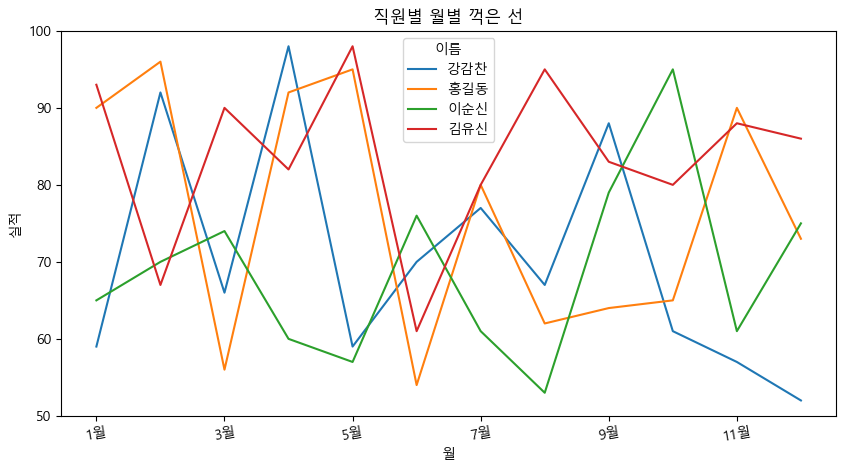

In [107]:
chartdata.plot(kind='line', figsize=(10, 5), ylim=[50, 100], grid=False, \
                rot=10, use_index=True)
plt.xlabel('월')
plt.ylabel('실적')
plt.title('직원별 월별 꺽은 선')

In [109]:
# 넓은 형식 데이터를 긴 형식으로 변환

In [110]:
siljuk_long = pd.melt(siljuk, id_vars =['이름'],
                var_name='월', value_name = '실적')
siljuk_long.head(8)

,이름,월,실적
0,강감찬,1월,59
1,홍길동,1월,90
2,이순신,1월,65
3,김유신,1월,93
4,강감찬,2월,92
5,홍길동,2월,96
6,이순신,2월,70
7,김유신,2월,67


In [111]:
# 특정인만 조회해 보기

In [112]:
result = siljuk_long.loc[siljuk_long['이름'] == '이순신']
result

,이름,월,실적
2,이순신,1월,65
6,이순신,2월,70
10,이순신,3월,74
14,이순신,4월,60
18,이순신,5월,57
22,이순신,6월,76
26,이순신,7월,61
30,이순신,8월,53
34,이순신,9월,79
38,이순신,10월,95


In [113]:
# 특정월만 조회해 보기

In [114]:
result = siljuk_long.loc[siljuk_long['월'] == '4월']
result

,이름,월,실적
12,강감찬,4월,98
13,홍길동,4월,92
14,이순신,4월,60
15,김유신,4월,82


In [115]:
# isin() 함수는 특정 조건에 만족하는 데이터에 대하여 True를 반환해주는 함수입니다.
# 데이터 베이스의 in 키워드와 유사한 개념입니다.
filter_dict = {'월':['1월', '3월']}
condition = siljuk_long.isin(filter_dict)
condition

,이름,월,실적
0,False,True,False
1,False,True,False
2,False,True,False
3,False,True,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,True,False
9,False,True,False


In [116]:
result = siljuk_long.loc[condition['월'] ]
result

,이름,월,실적
0,강감찬,1월,59
1,홍길동,1월,90
2,이순신,1월,65
3,김유신,1월,93
8,강감찬,3월,66
9,홍길동,3월,56
10,이순신,3월,74
11,김유신,3월,90


In [ ]:
# 영화 매출 데이터(pivot_table)

In [ ]:
# 영화 데이터 읽기

In [117]:
filename = dataIn + "movie_show.csv"
movie_show = pd.read_csv(filename, encoding='CP949')
movie_show

,gu,year,month,드라마,공포,액션
0,마포구,2020,1,10,20,10
1,용산구,2020,1,20,20,30
2,마포구,2020,2,30,10,10
3,용산구,2020,2,30,30,20
4,마포구,2020,3,10,20,10
5,용산구,2020,3,20,20,30


In [118]:
# 장르별 매출 분류하기

In [121]:
movie_show_melt = pd.melt(movie_show, id_vars=['gu', 'year', 'month'], \
                       var_name='genre', value_name='qty')
movie_show_melt.head()

,gu,year,month,genre,qty
0,마포구,2020,1,드라마,10
1,용산구,2020,1,드라마,20
2,마포구,2020,2,드라마,30
3,용산구,2020,2,드라마,30
4,마포구,2020,3,드라마,10


In [ ]:
# 구별, 년도별 월 매출 평균, 총합

In [124]:
# pivot_table() : 데이터를 재구성하여 요약된 형태로 표현(그룹화, 집계, 정리 등)하는 데 사용됩니다. 
# 특정 지역의 특정 월에 대하여 상영 회수의 평균 값을 보여 줍니다.
# aggfunc는 집계 함수(aggregate function)를 의미합니다.
# mean : 평균
pivoting = movie_show_melt.pivot_table(index=['gu', 'year'], columns='month', values='qty', aggfunc='mean')
pivoting

,month,1,2,3
gu,year,,,
마포구,2020,13.333333,16.666667,13.333333
용산구,2020,23.333333,26.666667,23.333333


In [125]:
pivoting = movie_show_melt.pivot_table(index=['gu', 'year'], columns='month', values='qty', aggfunc='sum')
pivoting # 총합

,month,1,2,3
gu,year,,,
마포구,2020,40,50,40
용산구,2020,70,80,70


In [ ]:
# 2개 이상의 컬럼에 대한 집계 (멀티 인덱스)

In [126]:
dict_aggfunc = {'genre':'count', 'qty':'mean'}

pivoting = movie_show_melt.pivot_table(
    index=['gu', 'year'], 
    columns='month', 
    values=['genre', 'qty'], 
    aggfunc=dict_aggfunc)
pivoting

genre              qty                      
month        1  2  3          1          2          3
gu  year                                             
마포구 2020     3  3  3  13.333333  16.666667  13.333333
용산구 2020     3  3  3  23.333333  26.666667  23.333333

In [127]:
# 특정 컬럼 1개에 대하여 여러 개의 함수를 적용합니다.
dict_aggfunc = {'qty':['mean', 'sum']}

pivoting = movie_show_melt.pivot_table(
    index=['gu', 'year'], 
    columns='genre', 
    values='qty', 
    aggfunc=dict_aggfunc)
pivoting

mean                       sum        
genre            공포        드라마         액션  공포 드라마  액션
gu  year                                             
마포구 2020  16.666667  16.666667  10.000000  50  50  30
용산구 2020  23.333333  23.333333  26.666667  70  70  80

In [ ]:
# 중첩 열 색인의 단순화(simplification)

In [128]:
# 내부와 외부 색인 사이에 언더바를 붙여서 renaming하기
outer = pivoting.columns.get_level_values(0) # 외부 색인
inner = pivoting.columns.get_level_values(1) # 내부 색인
print(outer, inner)
newColumns = inner + '_' + outer
pivoting.columns = newColumns
pivoting

Index(['mean', 'mean', 'mean', 'sum', 'sum', 'sum'], dtype='object') Index(['공포', '드라마', '액션', '공포', '드라마', '액션'], dtype='object', name='genre')


,,공포_mean,드라마_mean,액션_mean,공포_sum,드라마_sum,액션_sum
gu,year,,,,,,
마포구,2020,16.666667,16.666667,10.000000,50,50,30
용산구,2020,23.333333,23.333333,26.666667,70,70,80
